In [1]:
import json
import os
import urllib


def download_and_load_file(file_path, url):

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    # The book originally contained this unnecessary "else" clause:
    #else:
    #    with open(file_path, "r", encoding="utf-8") as file:
    #        text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [2]:
def format_input(entry: dict[str, str]) -> str:
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [3]:
def format_output(entry: dict[str, str]) -> str:
    return f"\n\n### Response:\n{entry['output']}\n"

def format_entry(entry: dict[str, str]) -> str:
    return format_input(entry) + format_output(entry)

In [4]:
print(format_entry(data[50]))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'



In [5]:
print(format_entry(data[999]))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.



In [6]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [7]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [8]:
from mlxgpt.model import create_gpt_model, GPTModel

CHOOSE_MODEL = "medium"  # Options: "small", "medium", "large"

# Create model
model: GPTModel = create_gpt_model(CHOOSE_MODEL)
print(f"Model context length: {model.context_length}")

Loading gpt2-medium (355M) model from cache...
Model loaded successfully from gpt2/GPT2-medium.npz
Model context length: 1024


In [9]:
from mlxgpt.gpt2 import generate, text_to_token_ids, token_ids_to_text

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=50,
    context_size=model.context_length,
    temperature=1.0
)
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Every effort moves you forward.

You are operating in neighborhoods with constantly evolving, highly diverse, and yet in close proximity. You're working in a world that's changing in an unprecedented way.

You've got multiple universes in your working life that you want


In [10]:
import mlx.core as mx
import mlx.data as mdx
import numpy as np
from typing import Optional

def create_instruction_dataset(data: list[dict[str, str]], tokenizer: tiktoken.Encoding, max_length: Optional[int] = None) -> mdx.Buffer:
    train_data = [format_entry(entry) for entry in data]
    buffer = mdx.buffer_from_vector([{"input_ids": tokenizer.encode(text)[:max_length]} for text in train_data])
    buffer = buffer.key_transform("input_ids", lambda ids: np.concatenate((ids[1:], [tokenizer.eot_token])), "target_ids")
    return buffer


In [11]:
max_length = model.context_length

train_set = create_instruction_dataset(train_data, tokenizer, max_length=max_length)
val_dset = create_instruction_dataset(val_data, tokenizer, max_length=max_length)
test_dset = create_instruction_dataset(test_data, tokenizer,max_length=max_length)
print("Training dataset size:", train_set.size())
print("Validation dataset size:", val_dset.size())
print("Test dataset size:", test_dset.size())

Training dataset size: 935
Validation dataset size: 55
Test dataset size: 110


In [12]:
for sample in train_set:
    print(f"{tokenizer.decode(sample['input_ids'])}\n{tokenizer.decode(sample['target_ids'])}")
    break

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend

### Response:
The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".

 is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend

### Response:
The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".
<|endoftext|>


In [13]:
from mlxgpt.dataloader import MLXDataLoader

batch_size = 8
train_loader = MLXDataLoader(train_set, 
                             batch_size=batch_size,
                             input_key="input_ids",
                             target_key="target_ids",
                             shuffle=True,
                             drop_last=True,
                             pad={"input_ids": tokenizer.eot_token, "target_ids": -100})

val_loader = MLXDataLoader(val_dset,
                           batch_size=batch_size,
                           input_key="input_ids",
                           target_key="target_ids",
                           shuffle=False,
                           drop_last=False,
                           pad={"input_ids": tokenizer.eot_token, "target_ids": -100})

test_loader = MLXDataLoader(test_dset,
                            batch_size=batch_size,
                            input_key="input_ids",
                            target_key="target_ids",
                            shuffle=False,
                            drop_last=False,
                            pad={"input_ids": tokenizer.eot_token, "target_ids": -100})

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 116
Number of validation batches: 7
Number of test batches: 14


In [14]:
for i, (x, y) in enumerate(train_loader):
    print(f"Batch {i}: {x.shape}, {y.shape}")
    if i < batch_size:
        print(f'Batch {i} sameple {i}:\n{tokenizer.decode([e for e in x[i].tolist() if e != tokenizer.eot_token])}\n{tokenizer.decode([e for e in y[i].tolist() if e != -100])}')
    if i > 10:
        break

Batch 0: (8, 62), (8, 62)
Batch 0 sameple 0:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the process by which plants make their food.

### Response:
The process by which plants make their food is called photosynthesis.

 is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the process by which plants make their food.

### Response:
The process by which plants make their food is called photosynthesis.
<|endoftext|>
Batch 1: (8, 61), (8, 61)
Batch 1 sameple 1:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Generate a sentence using the word 'gregarious.'

### Response:
He was known for his gregarious nature, always enjoying social gatherings.

 is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:

In [15]:
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [16]:
from mlxgpt.gpt2 import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=model.context_length,
    temperature=1.0,
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### First divide your text into manageable chunks to the an length, then to lower, then to Upper: Convert the varied elements of the sentence.

#


In [17]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

### First divide your text into manageable chunks to the an length, then to lower, then to Upper: Convert the varied elements of the sentence.

#


In [18]:
from mlxgpt.train import calc_loss_loader

model.eval()
train_loss = calc_loss_loader(model, train_loader, num_batches=5)
val_loss = calc_loss_loader(model, val_loader, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 6.42160816192627
Validation loss: 6.892503166198731


In [19]:
import time
import mlx.optimizers as optim
from mlxgpt.train import train_model_simple

start_time = time.time()

optimizer = optim.AdamW(learning_rate=0.00005, weight_decay=0.01)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer,
    use_compile=True
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Starting training...
Ep 1 (Step 000000): Train loss 3.076, Val loss 3.268
Ep 1 (Step 000005): Train loss 0.515, Val loss 0.890
Ep 1 (Step 000010): Train loss 0.416, Val loss 0.825
Ep 1 (Step 000015): Train loss 0.384, Val loss 0.755
Ep 1 (Step 000020): Train loss 0.373, Val loss 0.730
Ep 1 (Step 000025): Train loss 0.361, Val loss 0.703
Ep 1 (Step 000030): Train loss 0.378, Val loss 0.672
Ep 1 (Step 000035): Train loss 0.372, Val loss 0.656
Ep 1 (Step 000040): Train loss 0.362, Val loss 0.643
Ep 1 (Step 000045): Train loss 0.348, Val loss 0.634
Ep 1 (Step 000050): Train loss 0.340, Val loss 0.614
Ep 1 (Step 000055): Train loss 0.343, Val loss 0.605
Ep 1 (Step 000060): Train loss 0.350, Val loss 0.600
Ep 1 (Step 000065): Train loss 0.350, Val loss 0.590
Ep 1 (Step 000070): Train loss 0.354, Val loss 0.594
Ep 1 (Step 000075): Train loss 0.342, Val loss 0.601
Ep 1 (Step 000080): Train loss 0.335, Val loss 0.600
Ep 1 (Step 000085): Train loss 0.335, Val loss 0.585
Ep 1 (Step 000090): Train

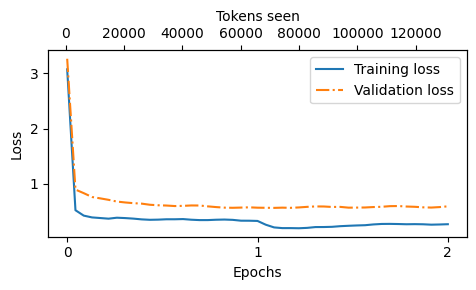

In [20]:
from mlxgpt.train import plot_losses

epochs_tensor = mx.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [21]:
for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer),
        max_new_tokens=256,
        context_size=model.context_length,
        eos_id=50256,
        temperature=0.0,
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet train.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cirrus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and

In [22]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer),
        max_new_tokens=256,
        context_size=model.context_length,
        temperature=0.0,
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

python3(14664) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [02:31<00:00,  1.38s/it]


In [23]:

file_name = f"gpt2-{CHOOSE_MODEL}-sft.npz"
model.save_weights(file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_weights(np.load("gpt2-medium-sft.npz"))

Model saved as gpt2-medium-sft.npz


In [24]:
SystemExit("Run SFT_eval.ipynb for model evaluation")

SystemExit('Run SFT_eval.ipynb for model evaluation')

In [25]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [26]:
# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [27]:
import urllib.request

def query_model(
    prompt,
    model="gemma3:27b",
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data


model = "gemma3:27b"
result = query_model("Answer in one sentence: What do Llamas eat?", model)
print(result)

Llamas primarily eat grasses, hay, and other vegetation, but can also consume shrubs and tree bark.






In [28]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
        f"Respond with only the numeric score first then a brief explanation in one line."
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet train.

Score:
>> 95

The response fulfills the request with a creative and appropriate simile, though "lightning" is a more common and slightly stronger comparison for speed.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud is a cirrus.

Score:
>> 0

The response is completely incorrect; cirrus clouds are associated with fair weather, not thunderstorms, and demonstrates a lack of understanding of cloud types.

-------------------------

Dataset response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is George Orwell.

Score:
>> 0

The response incorrectly identifies the author; George Orwell wrote '1984', not 'Pride and Prejudice'.

-------------------------


In [29]:
def generate_model_scores(json_data, json_key, model="gemma3:27b"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only and nothing else."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response", model=model)
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [02:01<00:00,  1.11s/it]

Number of scores: 110 of 110
Average score: 39.11

